# Placholder file (copy of HW7) for Datasci 3000 group project 


# Dataset Preperation (10%): 



In [6]:
# Imports
import numpy as np
import pandas as pd
import polars as pl
import sklearn.feature_extraction.text as sktext
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap
shap.initjs()

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Part 1: Data preparation

In [32]:
# load Demostats CSV: 

DemoStats_2020_CSV = pl.read_csv(
    "DemoStats_2025_CSV_fixed/DemoStats_(DST)_2020_2025_GEO.csv",
    schema_overrides={"CODE": pl.Utf8}
)

DemoStats_2025_CSV = pl.read_csv(
    "DemoStats_2025_CSV_fixed/DemoStats_(DST)_2025_2025_GEO.csv",
    schema_overrides={"CODE": pl.Utf8}
)

DemoStats_2028_CSV = pl.read_csv(
    "DemoStats_2025_CSV_fixed/DemoStats_(DST)_2028_2025_GEO.csv",
    schema_overrides={"CODE": pl.Utf8}
)

DemoStats_2030_CSV = pl.read_csv(
    "DemoStats_2025_CSV_fixed/DemoStats_(DST)_2030_2025_GEO.csv",
    schema_overrides={"CODE": pl.Utf8}
)

DemoStats_2035_CSV = pl.read_csv(
    "DemoStats_2025_CSV_fixed/DemoStats_(DST)_2035_2025_GEO.csv",
    schema_overrides={"CODE": pl.Utf8}
)

DemoStats_2020_CSV.describe()
DemoStats_2025_CSV.describe()
DemoStats_2028_CSV.describe()
DemoStats_2030_CSV.describe()
DemoStats_2035_CSV.describe()


statistic,CODE,GEO,P0YBASPOP,P0YBASHHD,P0YBASHPOP,P0YBAS12P,P0YBAS15P,P0YBAS18P,P0YBAS19P,P0YBAS12HP,P0YBAS15HP,P0YBAS18HP,P0YBAS19HP,P0YBASTNGH,P0YBASADUH,P0YBASCF,P0YBASCFH,P0YBASKID,P0YBASLF,P0YPTAPOP,P0YPTA_0_4,P0YPTA_5_9,P0YPTA1014,P0YPTA1519,P0YPTA2024,P0YPTA2529,P0YPTA3034,P0YPTA3539,P0YPTA4044,P0YPTA4549,P0YPTA5054,P0YPTA5559,P0YPTA6064,P0YPTA6569,P0YPTA7074,P0YPTA7579,…,P0YTIMA,P0YTIMWCA,P0YTIMAFGH,P0YTIMIRAN,P0YTIMIRAQ,P0YTIMISRA,P0YTIMLEBA,P0YTIMSAUD,P0YTIMSYRI,P0YTIMTURK,P0YTIMUAE,P0YTIMOWCA,P0YTIMEA,P0YTIMCHIN,P0YTIMHONG,P0YTIMJAPA,P0YTIMSKOR,P0YTIMTAIW,P0YTIMOEA,P0YTIMSEA,P0YTIMCAMB,P0YTIMMALA,P0YTIMPHIL,P0YTIMVIET,P0YTIMOSEA,P0YTIMSA,P0YTIMBANG,P0YTIMINDI,P0YTIMNEPA,P0YTIMPAKI,P0YTIMSRI,P0YTIMOSA,P0YTIMOCE,P0YTIMAUSS,P0YTIMFIJI,P0YTIMOOCE,P0YTIMNPER
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""77263""","""77263""",77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,…,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0,77263.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,6466.337277,2526.431552,6344.697048,5747.572654,5560.371277,5352.182015,5282.810686,5625.092761,5441.093499,5242.960796,5173.193676,382.132081,3315.682099,1752.356639,1655.170107,1668.525892,3599.469526,6466.337277,289.203267,304.776167,311.985362,346.951723,421.188434,435.320904,435.854782,467.953328,475.725755,436.515266,398.811928,356.332035,335.381412,333.064921,357.161837,309.50165,…,1078.953548,190.602954,23.229605,46.429468,20.151496,6.564539,22.864295,8.047694,20.425883,9.469837,7.811359,25.608739,267.335827,161.316529,49.736743,7.349326,32.81849,14.478664,1.636126,240.593259,4.404864,5.743331,169.62849,43.627467,17.189146,380.421612,17.735811,269.129079,5.189962,57.285661,30.361273,0.720086,12.915859,5.883437,4.66671,2.365777,326.650039
"""std""",null,null,211172.249097,82148.304212,207321.550282,187750.925529,181666.303563,174893.09437,172636.087764,183864.699695,177887.639499,171448.578092,169180.606615,12430.949286,108436.040376,57215.5474,53942.906384,55021.49498,117788.633071,211172.249097,9444.522737,9938.238434,10153.458443,11296.349121,13859.364059,14330.776079,14326.918992,15345.408,15594.705894,14243.990574,12952.269426,11579.786195,10947.157655,10905.141023,11677.45715,10089.0048,…,38478.905545,6925.503672,857.028522,1791.797242,809.536875,246.037824,846.671794,306.228137,709.436002,359.444348,299.14402,936.021648,10041.065491,6024.909546,1968.573786,269.905867,1208.069608,622.012177,60.195569,8167.720308,159.554446,210.982234,5800.922894,1516.263671,582.349907,14191.231531,697.368634,9842.899909,191.885231,2269.200838,1367.420661,30.43465,471.321569,200.291125,206.022151,82.986678,11297.421402
"""min""","""000""","""CAN""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,null,459

In [30]:
# Load Geographic Hierarchy CSV files with tolerant UTF-8 decoding
Geograph_Hier_File_df = pl.read_csv(
    "Geographic Hierarchy File_2025_CSV/Geography_Hierarchy_File_2025.csv",
    encoding="utf8-lossy",
    infer_schema_length=10000
)

Geograph_Hier_List_df = pl.read_csv(
    "Geographic Hierarchy File_2025_CSV/Geography_Hierarchy_List_2025.csv",
    encoding="utf8-lossy",
    infer_schema_length=10000
)

Geograph_Hier_File_df.describe()
Geograph_Hier_List_df.describe()

statistic,PRCDDA,PRABB,CODE,GEO,ORDER,NAME,NAMEE,NAMEF,LBL,LBLE,LBLF,TYPE,TYPEN,TYPENE,TYPENF,RELEASED
str,f64,str,f64,str,f64,str,str,str,str,str,str,str,str,str,str,f64
"""count""",753168.0,"""753168""",753168.0,"""753168""",753168.0,"""753168""","""753168""","""753168""","""753168""","""753168""","""753168""","""173808""","""173808""","""173808""","""173808""",753168.0
"""null_count""",0.0,"""0""",0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""579360""","""579360""","""579360""","""579360""",0.0
"""mean""",3.6546e7,null,6.8178e6,null,7.615385,null,null,null,null,null,null,null,null,null,null,0.668134
"""std""",1.3319e7,null,1.3883e7,null,3.563459,null,null,null,null,null,null,null,null,null,null,0.470884
"""min""",1.0010165e7,"""AB""",0.0,"""CAN""",2.0,"""10010001, NL""","""10010001, NL""","""10010001, NL""","""10010001""","""10010001""","""10010001""","""1""","""CMA / RMR""","""CMA""","""Canton (municipalit� de)""",0.0
"""25%""",2.4662901e7,null,35.0,null,5.0,null,null,null,null,null,null,null,null,null,null,0.0
"""50%""",3.5212108e7,null,5920.0,null,7.0,null,null,null,null,null,null,null,null,null,null,1.0
"""75%""",4.7170231e7,null,5.0501e6,null,10.0,null,null,null,null,null,null,null,null,null,null,1.0
"""max""",6.2080028e7,"""YT""",6.2080028e7,"""REG""",14.0,"""�le-�-la-Crosse, SK (NV)""","""�le-�-la-Crosse, SK (NV)""","""�le-�-la-Crosse, SK (NV)""","""�le-�-la-Crosse""","""�le-�-la-Crosse""","""�le-�-la-Crosse""","""VN""","""Weak MIZ / ZIM faible""","""Weak MIZ""","""ZIM sans influence""",1.0


In [ ]:
# Load HouseholdSpend CSV
HouseholdSpend_2025_CSV_fixed = pl.read_csv(
    "HouseholdSpend_2025_CSV_fixed/HouseholdSpend_(HHS)_2025_GEO_P1.csv",
    schema_overrides={"CODE": pl.Utf8},
    ignore_errors=False
)

HouseholdSpend_2025_CSV_fixed_P2 = pl.read_csv(
    "HouseholdSpend_2025_CSV_fixed/HouseholdSpend_(HHS)_2025_GEO_P2.csv",
    schema_overrides={"CODE": pl.Utf8},
    ignore_errors=False
)

HouseholdSpend_2025_CSV_fixed.describe()
HouseholdSpend_2025_CSV_fixed_P2.describe()

statistic,CODE,GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSSH001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,…,HSRE116,HSRE076,HSRE050,HSRE051M,HSRE052,HSRE060,HSRE061,HSRE067,HSRE062,HSRE063,HSRE064,HSRE065,HSRE066,HSRE091,HSRE146,HSRE073,HSRE074,HSRE142,HSRV001,HSRV020,HSRV003,HSRV003A,HSRV003B,HSRV004,HSRV007,HSRV005,HSRV005B,HSRV005M1,HSRV005M2,HSRV010,HSRV011,HSRV012,HSRV016,HSRV081,HSRV013,HSRV021,HSRV022
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""950157""","""950157""",950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,…,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0,950157.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,201.425804,2.5973e7,2.0121e7,1.3020e7,2.8179e7,2.3572e7,4.9718e6,1.6858e7,2.5268e6,1.2586e6,709883.581947,2.5274e6,646709.715584,391028.547374,1.0948e6,46661.756417,904054.66312,280811.844783,362753.50389,5.1763e6,575024.510091,357365.896367,1.4349e6,307120.999748,4.6073e6,3.4636e6,208589.608153,198447.97478,704797.718776,31885.161745,2.5268e6,1.8160e6,703222.592831,647583.548446,…,27674.734519,6316.980689,3818.924229,2498.05646,7848.331807,540455.579602,184870.018951,116661.262485,13481.464785,41877.211628,16446.644894,25430.566734,12850.080053,101102.155219,82599.062797,18503.092422,231459.786977,23023.618455,188530.325093,134228.044355,26377.008839,18433.11987,7943.888969,9397.297795,24737.317148,73716.420573,32117.39247,24919.725993,16679.30211,54302.280737,12094.293855,4499.672212,6916.086782,30792.227889,3077.334547,10889.630014,16825.263327
"""std""",null,null,21048.4064,2.7394e9,2.1206e9,1.3718e9,2.9899e9,2.4766e9,5.2725e8,1.7678e9,2.6311e8,1.3141e8,7.4711e7,2.6316e8,6.7233e7,4.0631e7,1.1387e8,5.0507e6,9.3032e7,2.9804e7,3.8082e7,5.5126e8,6.0736e7,3.8590e7,1.5011e8,3.2606e7,5.2435e8,4.0559e8,2.7008e7,2.8452e7,7.5539e7,3.3894e6,2.6311e8,1.8900e8,7.3461e7,6.7601e7,…,2.9010e6,659136.386263,398754.83958,260417.895525,844168.350793,5.6528e7,1.9180e7,1.2081e7,1.4039e6,4.3652e6,1.7147e6,2.6507e6,1.3399e6,1.0599e7,8.6052e6,2.0177e6,2.4434e7,2.3800e6,1.9226e7,1.3652e7,2.7416e6,1.9158e6,838823.918934,975153.962405,2.5449e6,7.5524e6,3.2881e6,2.5571e6,1.7099e6,5.5901e6,1.2680e6,476951.33984,734059.896511,3.1587e6,323643.4975,1.1113e6,1.7284e6
"""min""","""000""","""CAN""",0.0,0.0,0.0,-1.3613e6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.3444e6,-8.2164e6,-6.5160e8,-3.2821e9,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,null,3.0,323099.422301,265012.151786,159844.92185,362441.586654,315340.691264,41026.915141,243557.233775,39713.452473,19113.40922

## Question 1. a)

The raw CSVs contain several geographic levels in the GEO column (province, CMA,
CSD, PRCDDA, etc.). Filter your data to focus on PRCDDA (Dissemination Area).

In [38]:
# Filter each dataset to PRCDDA geographic level
def filter_to_prcdda(df: pl.DataFrame, geo_col: str = "GEO") -> pl.DataFrame:
    return df.filter(
        pl.col(geo_col)
        .cast(pl.Utf8)
        .str.to_uppercase()
        .str.contains(r"\bPRCDDA\b")
    )

DemoStats_2020_PRCDDA = filter_to_prcdda(DemoStats_2020_CSV)
DemoStats_2025_PRCDDA = filter_to_prcdda(DemoStats_2025_CSV)
DemoStats_2028_PRCDDA = filter_to_prcdda(DemoStats_2028_CSV)
DemoStats_2030_PRCDDA = filter_to_prcdda(DemoStats_2030_CSV)
DemoStats_2035_PRCDDA = filter_to_prcdda(DemoStats_2035_CSV)
HouseholdSpend_P1_PRCDDA = filter_to_prcdda(HouseholdSpend_2025_CSV_fixed)
HouseholdSpend_P2_PRCDDA = filter_to_prcdda(HouseholdSpend_2025_CSV_fixed_P2)

print("Rows after PRCDDA filter:")
print("DemoStats 2020:", DemoStats_2020_PRCDDA.height)
print("DemoStats 2025:", DemoStats_2025_PRCDDA.height)
print("DemoStats 2028:", DemoStats_2028_PRCDDA.height)
print("DemoStats 2030:", DemoStats_2030_PRCDDA.height)
print("DemoStats 2035:", DemoStats_2035_PRCDDA.height)
print("HouseholdSpend P1:", HouseholdSpend_P1_PRCDDA.height)
print("HouseholdSpend P2:", HouseholdSpend_P2_PRCDDA.height)

display(DemoStats_2020_PRCDDA.head(5))
display(DemoStats_2025_PRCDDA.head(5))
display(DemoStats_2028_PRCDDA.head(5))
display(DemoStats_2030_PRCDDA.head(5))
display(DemoStats_2035_PRCDDA.head(5))
display(HouseholdSpend_P1_PRCDDA.head(5))
display(HouseholdSpend_P2_PRCDDA.head(5))


# dont have column GEO in these files, so we will filter by CODE instead
# Geograph_Hier_File_PRCDDA = filter_to_prcdda(Geograph_Hier_File_df)
# Geograph_Hier_List_PRCDDA = filter_to_prcdda(Geograph_Hier_List_df)
# print("Geograph Hier File:", Geograph_Hier_File_PRCDDA.height)
# print("Geograph Hier List:", Geograph_Hier_List_PRCDDA.height)
# display(Geograph_Hier_File_PRCDDA.head(5))
# display(Geograph_Hier_List_PRCDDA.head(5))

Rows after PRCDDA filter:
DemoStats 2020: 57936
DemoStats 2025: 57936
DemoStats 2028: 57936
DemoStats 2030: 57936
DemoStats 2035: 57936
HouseholdSpend P1: 57936
HouseholdSpend P2: 57936


CODE,GEO,EHYBASPOP,EHYBASHHD,EHYBASHPOP,EHYBAS12P,EHYBAS15P,EHYBAS18P,EHYBAS19P,EHYBAS12HP,EHYBAS15HP,EHYBAS18HP,EHYBAS19HP,EHYBASTNGH,EHYBASADUH,EHYBASCF,EHYBASCFH,EHYBASKID,EHYBASLF,EHYPTAPOP,EHYPTA_0_4,EHYPTA_5_9,EHYPTA1014,EHYPTA1519,EHYPTA2024,EHYPTA2529,EHYPTA3034,EHYPTA3539,EHYPTA4044,EHYPTA4549,EHYPTA5054,EHYPTA5559,EHYPTA6064,EHYPTA6569,EHYPTA7074,EHYPTA7579,EHYPTA8084,…,EHYTIMA,EHYTIMWCA,EHYTIMAFGH,EHYTIMIRAN,EHYTIMIRAQ,EHYTIMISRA,EHYTIMLEBA,EHYTIMSAUD,EHYTIMSYRI,EHYTIMTURK,EHYTIMUAE,EHYTIMOWCA,EHYTIMEA,EHYTIMCHIN,EHYTIMHONG,EHYTIMJAPA,EHYTIMSKOR,EHYTIMTAIW,EHYTIMOEA,EHYTIMSEA,EHYTIMCAMB,EHYTIMMALA,EHYTIMPHIL,EHYTIMVIET,EHYTIMOSEA,EHYTIMSA,EHYTIMBANG,EHYTIMINDI,EHYTIMNEPA,EHYTIMPAKI,EHYTIMSRI,EHYTIMOSA,EHYTIMOCE,EHYTIMAUSS,EHYTIMFIJI,EHYTIMOOCE,EHYTIMNPER
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""10010165""","""PRCDDA""",519,233,519,482,473,453,447,481,473,454,448,27,277,167,158,128,284,519,15,16,15,33,34,40,27,20,24,34,34,47,51,59,40,21,2,…,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,0,0,10,7,0,0,0,0,0,0,0,0,0,0,0,0,1
"""10010166""","""PRCDDA""",347,152,347,307,300,290,287,307,300,291,288,16,168,99,99,83,180,347,19,17,11,16,22,23,16,16,14,21,18,20,40,36,31,19,8,…,9,4,0,0,0,0,0,0,3,0,0,1,0,0,0,0,0,0,0,4,0,0,4,0,0,1,0,0,0,1,0,0,0,0,0,0,6
"""10010167""","""PRCDDA""",426,196,426,392,379,369,365,392,379,369,366,23,204,133,133,94,168,426,14,12,21,17,22,18,21,20,20,28,18,29,50,51,46,24,9,…,7,3,0,0,0,0,0,0,2,0,0,1,0,0,0,0,0,0,0,4,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,6
"""10010168""","""PRCDDA""",539,248,539,499,486,474,470,498,486,474,470,24,284,159,158,118,273,539,16,15,22,20,39,31,34,23,36,38,40,38,44,52,37,27,16,…,6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,4,0,1,0,3,0,0,0,0,0,0,7
"""10010169""","""PRCDDA""",299,130,299,272,263,254,251,272,263,255,252,17,166,93,93,76,146,299,10,11,15,15,23,22,20,19,17,20,15,32,21,20,23,6,9,…,4,2,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,2,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


CODE,GEO,ECYASQKM,ECYALSQKM,ECYBASPOP,ECYBASHHD,ECYBASHPOP,ECYBAS12P,ECYBAS15P,ECYBAS18P,ECYBAS19P,ECYBAS12HP,ECYBAS15HP,ECYBAS18HP,ECYBAS19HP,ECYBASTNGH,ECYBASADUH,ECYBASCF,ECYBASCFH,ECYBASKID,ECYBASLF,ECYPTAPOP,ECYPTA_0_4,ECYPTA_5_9,ECYPTA1014,ECYPTA1519,ECYPTA2024,ECYPTA2529,ECYPTA3034,ECYPTA3539,ECYPTA4044,ECYPTA4549,ECYPTA5054,ECYPTA5559,ECYPTA6064,ECYPTA6569,ECYPTA7074,…,ECYRIMINDI,ECYRIMNEPA,ECYRIMPAKI,ECYRIMSRI,ECYRIMSASO,ECYRIMOCE,ECYRIMAUSS,ECYRIMOCEO,ECYPIMHPOP,ECYPIMNI,ECYPIMIM,ECYPIMP01,ECYPIM0110,ECYPIM1115,ECYPIM1621,ECYPIM22CY,ECYPIMNPER,ECYAIMHPOP,ECYAIMNI,ECYAIMIM,ECYAIM_0_5,ECYAIM_514,ECYAIM1524,ECYAIM2544,ECYAIM45P,ECYAIMNPER,ECYGENHPOP,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCAHPOP,ECYTCACIT,ECYTCA_U18,ECYTCA_18P,ECYNCANCIT,ECYNCA_U18,ECYNCA_18P
str,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""10010165""","""PRCDDA""",0.38455,0.38455,512,227,512,478,466,446,442,474,466,452,447,22,257,164,154,128,290,512,15,17,14,25,32,37,36,29,26,29,26,33,41,52,45,…,0,0,0,0,0,0,0,0,512,471,37,5,1,0,10,21,4,512,471,37,6,13,11,0,7,4,512,41,26,445,512,512,60,452,0,0,0
"""10010166""","""PRCDDA""",0.095564,0.095564,354,148,354,322,309,297,294,319,309,301,298,18,159,97,97,80,187,354,10,19,16,15,20,25,23,19,17,19,15,16,25,35,31,…,0,0,3,0,0,0,0,0,354,284,53,11,4,2,8,28,17,354,284,53,9,14,15,6,9,17,354,70,18,266,354,354,53,301,0,0,0
"""10010167""","""PRCDDA""",0.126296,0.126296,477,217,477,447,431,413,410,441,431,420,415,21,215,147,147,98,202,477,12,16,18,21,24,26,26,26,25,29,23,23,37,51,47,…,0,0,0,0,0,0,0,0,477,420,37,4,0,1,10,22,20,477,420,37,7,8,16,0,6,20,477,57,22,398,477,425,52,373,52,5,47
"""10010168""","""PRCDDA""",0.191336,0.191336,580,256,580,539,521,503,498,533,521,507,502,26,302,164,163,126,309,580,18,20,21,24,34,39,42,35,37,40,34,36,39,48,42,…,13,0,1,0,0,0,0,0,580,499,73,0,7,5,18,43,8,580,499,73,3,0,0,69,1,8,580,81,37,462,580,537,69,468,43,4,39
"""10010169""","""PRCDDA""",0.06591,0.06591,326,132,326,302,288,275,273,296,288,278,275,18,178,94,94,79,167,326,11,13,14,17,20,24,26,25,23,22,15,20,23,23,20,…,0,0,0,0,0,0,0,0,326,304,22,0,13,0,0,9,0,326,304,22,4,5,7,3,3,0,326,22,13,291,326,326,48,278,0,0,0


CODE,GEO,P3YBASPOP,P3YBASHHD,P3YBASHPOP,P3YBAS12P,P3YBAS15P,P3YBAS18P,P3YBAS19P,P3YBAS12HP,P3YBAS15HP,P3YBAS18HP,P3YBAS19HP,P3YBASTNGH,P3YBASADUH,P3YBASCF,P3YBASCFH,P3YBASKID,P3YBASLF,P3YPTAPOP,P3YPTA_0_4,P3YPTA_5_9,P3YPTA1014,P3YPTA1519,P3YPTA2024,P3YPTA2529,P3YPTA3034,P3YPTA3539,P3YPTA4044,P3YPTA4549,P3YPTA5054,P3YPTA5559,P3YPTA6064,P3YPTA6569,P3YPTA7074,P3YPTA7579,P3YPTA8084,…,P3YTIMA,P3YTIMWCA,P3YTIMAFGH,P3YTIMIRAN,P3YTIMIRAQ,P3YTIMISRA,P3YTIMLEBA,P3YTIMSAUD,P3YTIMSYRI,P3YTIMTURK,P3YTIMUAE,P3YTIMOWCA,P3YTIMEA,P3YTIMCHIN,P3YTIMHONG,P3YTIMJAPA,P3YTIMSKOR,P3YTIMTAIW,P3YTIMOEA,P3YTIMSEA,P3YTIMCAMB,P3YTIMMALA,P3YTIMPHIL,P3YTIMVIET,P3YTIMOSEA,P3YTIMSA,P3YTIMBANG,P3YTIMINDI,P3YTIMNEPA,P3YTIMPAKI,P3YTIMSRI,P3YTIMOSA,P3YTIMOCE,P3YTIMAUSS,P3YTIMFIJI,P3YTIMOOCE,P3YTIMNPER
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""10010165""","""PRCDDA""",500,222,500,461,451,439,435,462,451,440,436,22,246,160,151,127,278,500,15,18,16,20,25,32,38,32,27,29,24,28,36,47,45,35,22,…,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,45,0,0,0,45,0,0,0,0,0,0,0,0,0,0,0,0,3
"""10010166""","""PRCDDA""",346,145,346,314,304,294,290,315,304,295,292,20,153,95,95,77,185,346,9,16,17,17,17,21,24,21,18,18,15,15,21,31,30,26,19,…,38,13,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,0,0,21,0,0,4,0,0,0,4,0,0,0,0,0,0,12
"""10010167""","""PRCDDA""",476,217,476,440,429,417,413,441,429,418,414,23,210,147,147,99,200,476,12,16,19,20,22,24,28,27,26,28,23,23,31,46,47,40,28,…,33,10,0,0,0,0,0,0,2,0,0,8,0,0,0,0,0,0,0,23,0,0,23,0,0,0,0,0,0,0,0,0,0,0,0,0,15
"""10010168""","""PRCDDA""",580,256,580,534,521,507,502,535,521,508,503,27,301,164,163,126,306,580,16,21,22,24,28,35,43,39,37,40,33,35,39,46,43,35,26,…,29,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,3,0,0,9,0,0,9,0,0,17,0,17,0,0,0,0,0,0,0,0,5
"""10010169""","""PRCDDA""",322,131,322,292,283,273,270,294,283,274,271,20,172,93,93,79,161,322,11,13,15,16,17,20,25,24,23,23,17,18,22,24,21,15,11,…,18,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0


CODE,GEO,P5YBASPOP,P5YBASHHD,P5YBASHPOP,P5YBAS12P,P5YBAS15P,P5YBAS18P,P5YBAS19P,P5YBAS12HP,P5YBAS15HP,P5YBAS18HP,P5YBAS19HP,P5YBASTNGH,P5YBASADUH,P5YBASCF,P5YBASCFH,P5YBASKID,P5YBASLF,P5YPTAPOP,P5YPTA_0_4,P5YPTA_5_9,P5YPTA1014,P5YPTA1519,P5YPTA2024,P5YPTA2529,P5YPTA3034,P5YPTA3539,P5YPTA4044,P5YPTA4549,P5YPTA5054,P5YPTA5559,P5YPTA6064,P5YPTA6569,P5YPTA7074,P5YPTA7579,P5YPTA8084,…,P5YTIMA,P5YTIMWCA,P5YTIMAFGH,P5YTIMIRAN,P5YTIMIRAQ,P5YTIMISRA,P5YTIMLEBA,P5YTIMSAUD,P5YTIMSYRI,P5YTIMTURK,P5YTIMUAE,P5YTIMOWCA,P5YTIMEA,P5YTIMCHIN,P5YTIMHONG,P5YTIMJAPA,P5YTIMSKOR,P5YTIMTAIW,P5YTIMOEA,P5YTIMSEA,P5YTIMCAMB,P5YTIMMALA,P5YTIMPHIL,P5YTIMVIET,P5YTIMOSEA,P5YTIMSA,P5YTIMBANG,P5YTIMINDI,P5YTIMNEPA,P5YTIMPAKI,P5YTIMSRI,P5YTIMOSA,P5YTIMOCE,P5YTIMAUSS,P5YTIMFIJI,P5YTIMOOCE,P5YTIMNPER
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""10010165""","""PRCDDA""",499,221,499,460,450,439,435,462,450,440,436,22,243,159,150,127,274,499,14,18,17,19,24,28,39,34,29,29,24,27,33,44,45,36,25,…,50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,0,0,0,50,0,0,0,0,0,0,0,0,0,0,0,0,3
"""10010166""","""PRCDDA""",343,143,343,312,302,292,288,313,302,292,289,21,152,94,94,75,185,343,10,14,17,17,18,18,25,23,19,19,15,14,19,28,29,25,20,…,42,14,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,23,0,0,23,0,0,5,0,0,0,5,0,0,0,0,0,0,12
"""10010167""","""PRCDDA""",481,219,481,446,435,423,419,447,435,424,420,23,211,148,148,98,202,481,12,16,18,20,23,22,30,28,27,29,24,23,28,43,47,40,31,…,39,12,0,0,0,0,0,0,2,0,0,10,0,0,0,0,0,0,0,27,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,0,15
"""10010168""","""PRCDDA""",585,258,585,539,526,512,507,540,526,512,507,28,302,166,165,127,308,585,16,21,22,24,28,30,45,42,38,41,34,34,38,46,44,35,27,…,32,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,3,0,0,10,0,0,10,0,0,19,0,19,0,0,0,0,0,0,0,0,6
"""10010169""","""PRCDDA""",321,130,321,292,284,274,271,294,284,275,272,19,172,93,93,77,163,321,10,13,14,16,17,18,26,25,24,24,18,17,20,24,21,16,11,…,21,9,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0


CODE,GEO,P0YBASPOP,P0YBASHHD,P0YBASHPOP,P0YBAS12P,P0YBAS15P,P0YBAS18P,P0YBAS19P,P0YBAS12HP,P0YBAS15HP,P0YBAS18HP,P0YBAS19HP,P0YBASTNGH,P0YBASADUH,P0YBASCF,P0YBASCFH,P0YBASKID,P0YBASLF,P0YPTAPOP,P0YPTA_0_4,P0YPTA_5_9,P0YPTA1014,P0YPTA1519,P0YPTA2024,P0YPTA2529,P0YPTA3034,P0YPTA3539,P0YPTA4044,P0YPTA4549,P0YPTA5054,P0YPTA5559,P0YPTA6064,P0YPTA6569,P0YPTA7074,P0YPTA7579,P0YPTA8084,…,P0YTIMA,P0YTIMWCA,P0YTIMAFGH,P0YTIMIRAN,P0YTIMIRAQ,P0YTIMISRA,P0YTIMLEBA,P0YTIMSAUD,P0YTIMSYRI,P0YTIMTURK,P0YTIMUAE,P0YTIMOWCA,P0YTIMEA,P0YTIMCHIN,P0YTIMHONG,P0YTIMJAPA,P0YTIMSKOR,P0YTIMTAIW,P0YTIMOEA,P0YTIMSEA,P0YTIMCAMB,P0YTIMMALA,P0YTIMPHIL,P0YTIMVIET,P0YTIMOSEA,P0YTIMSA,P0YTIMBANG,P0YTIMINDI,P0YTIMNEPA,P0YTIMPAKI,P0YTIMSRI,P0YTIMOSA,P0YTIMOCE,P0YTIMAUSS,P0YTIMFIJI,P0YTIMOOCE,P0YTIMNPER
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""10010165""","""PRCDDA""",498,220,498,459,448,436,432,459,448,437,433,22,241,158,149,128,272,498,14,17,19,20,22,23,31,40,35,32,28,24,28,36,42,38,26,…,65,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,65,0,0,0,65,0,0,0,0,0,0,0,0,0,0,0,0,3
"""10010166""","""PRCDDA""",341,142,341,313,303,292,289,314,303,293,290,21,158,93,93,72,189,341,10,12,16,18,18,17,21,27,23,21,18,14,17,21,27,25,19,…,52,16,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,0,0,30,0,0,6,0,0,0,6,0,0,0,0,0,0,12
"""10010167""","""PRCDDA""",482,219,482,447,436,423,418,447,436,424,419,23,218,148,148,98,206,482,12,15,19,22,23,22,26,34,30,30,27,23,26,33,42,40,30,…,52,15,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,37,0,0,37,0,0,0,0,0,0,0,0,0,0,0,0,0,15
"""10010168""","""PRCDDA""",586,258,586,541,527,513,508,542,527,513,508,29,300,166,165,127,305,586,16,20,23,24,26,26,35,48,43,42,38,33,35,40,45,39,28,…,41,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,3,0,0,13,0,0,13,0,0,25,0,25,0,0,0,0,0,0,0,0,5
"""10010169""","""PRCDDA""",319,129,319,292,284,275,272,294,284,276,273,18,169,92,92,75,159,319,9,12,14,15,16,16,20,27,25,25,22,17,17,21,22,18,12,…,28,11,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,0,0,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0


CODE,GEO,HSBASHHD,HSHNIAGG,HSAGDISPIN,HSAGDISCIN,HSTT001,HSTE001,HSTX001,HSTC001,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,HSGC001S,HSME001S,HSSH001S,HSCL030S,HSED002S,HSEP011S,HSMG001S,HSTE001ZBS,HSWH040S,HSWH041S,HSWH042S,HSWH050S,HSWH028S,HSFD001,HSFD003,HSFD990,HSFD991,HSFD992,…,HSRE116,HSRE076,HSRE050,HSRE051M,HSRE052,HSRE060,HSRE061,HSRE067,HSRE062,HSRE063,HSRE064,HSRE065,HSRE066,HSRE091,HSRE146,HSRE073,HSRE074,HSRE142,HSRV001,HSRV020,HSRV003,HSRV003A,HSRV003B,HSRV004,HSRV007,HSRV005,HSRV005B,HSRV005M1,HSRV005M2,HSRV010,HSRV011,HSRV012,HSRV016,HSRV081,HSRV013,HSRV021,HSRV022
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10010165""","""PRCDDA""",227,2.6823e7,2.0393e7,1.3607e7,2.6448e7,2.4335e7,5.4431e6,1.6920e7,2.8802e6,1.3292e6,711659.516933,2.3899e6,668630.235525,448684.510062,1.1229e6,45068.095948,1.3539e6,286903.223949,521569.264355,4.1619e6,682510.148428,316776.330095,1.7466e6,225817.930939,2.1129e6,1.3293e6,38816.692833,153936.025409,508384.183685,82488.418384,2.8802e6,2.1452e6,726140.816749,659787.446427,414699.524849,…,27321.562209,5949.970576,3489.383877,2460.586699,5600.974686,552123.61542,272465.360189,201737.223794,13270.8546,43156.839745,17099.001088,26057.838657,14300.44205,101582.318301,87930.716968,13651.601333,168952.226948,9123.709982,208259.913122,161646.395867,67019.02732,28102.841628,38916.185692,8653.063542,15356.875843,70617.429161,32957.150594,27410.09404,10250.184526,46613.517256,9174.44121,2039.353414,2984.234962,32415.487669,1546.667326,14104.011398,16764.808945
"""10010166""","""PRCDDA""",148,2.0631e7,1.5006e7,1.0447e7,1.8951e7,1.8333e7,5.0019e6,1.2031e7,1.9633e6,917801.114063,462765.977777,1.6211e6,492538.611137,293616.580828,744282.628052,38154.948342,1.1123e6,234750.931935,596078.812838,2.9059e6,468390.839918,179796.878952,1.0916e6,208919.647015,617422.77719,321345.848273,-126878.961955,61061.166886,316468.673457,45426.050528,1.9633e6,1.4837e6,474285.486279,432047.282283,264205.521941,…,17157.96837,3130.117245,1923.278811,1206.838434,4006.163698,385542.89647,197302.382771,153442.152389,8110.554765,27175.134555,10686.792506,16488.342049,8574.541063,64000.152074,55608.651418,8391.500655,119094.746643,5145.614982,138431.708971,102990.794619,36564.42254,15903.751311,20660.671228,6125.542897,10425.790334,49875.038848,20033.402642,21056.738794,8784.897412,35440.914352,7576.279108,1471.635922,3013.847946,23379.151376,1012.972958,10037.311127,12328.867291
"""10010167""","""PRCDDA""",217,2.4982e7,1.9145e7,1.2877e7,2.3245e7,2.2511e7,5.0357e6,1.5746e7,2.7642e6,1.2585e6,630450.46807,2.1013e6,760045.201358,413603.393883,997953.012331,60993.430883,1.2591e6,357350.018738,517663.710192,3.8005e6,598695.039498,226121.093801,1.4443e6,284418.80816,734479.491209,310988.106613,-150342.179678,75381.907699,432367.518781,66084.137795,2.7642e6,2.1137e6,641921.340789,586159.817413,353019.558401,…,21978.543283,3967.393466,2618.598459,1348.795006,5392.884721,532376.584622,294660.193203,233852.640822,10761.919101,38560.539158,15559.316154,23001.223004,11485.094122,78482.944105,66556.735922,11926.208183,152562.509861,6670.937452,173926.392534,129689.056678,45683.395359,18356.014225,27327.381134,7986.809587,13750.734896,62268.116835,28831.655523,21384.890533,12051.57078,44237.335856,9466.826441,1871.720556,3844.326126,29054.462733,1190.08065,12437.225968,15427.156115
"""10010168""","""PRCDDA""",256,2.9207e7,2.2279e7,1.4973e7,2.7666e7,2.6518e7,5.9072e6,1.8527e7,3.1922e6,1.4568e6,743198.496523,2.5697e6,844515.876136,483194.397362,1.1689e6,62657.604077,1.5144e6,390936.799146,638356.259886,4.4527e6,709557.837645,299983.444792,1.7747e6,309317.801601,1.1479e6,560185.511791,-145281.203037,144361.347131,508494.901103,80127.809122,3.1922e6,2.4

CODE,GEO,HSRO001,HSRO002,HSRO003,HSRO005,HSRO004,HSRO010,HSTA018,HSTA005,HSTA006,HSTA007,HSTA009,HSTA010,HSTA008,HSTA002,HSTA020,HSTA015,HSTA016,HSGC001,HSGC002,HSGC003,HSGC010,HSGC003A,HSGC003B,HSGC003C,HSME001,HSME040,HSME036,HSME012,HSME045,HSME014,HSME037,HSME016,HSME017,HSME024,HSME021,…,HSMG003,HSMG004,HSMG010,HSMG009,HSTE001ZB,HSWH040,HSWH021,HSWH022,HSWH041,HSWH026,HSWH027,HSWH042,HSWH031,HSWH032,HSWH050,HSOI030Z,HSOI030,HSWH028,HSWH050B,HSWH003A,HSWH003B,HSWH005,HSWH006,HSWH007,HSWH008,HSWH009M,HSWH010A,HSWH010B,HSWH011,HSWH012,HSWH013,HSWH014,HSWH015,HSWH016,HSWH017,HSWH100,HSWH101
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10010165""","""PRCDDA""",45068.095948,4264.032903,2234.10459,3594.42193,31739.554862,3235.981662,1.3539e6,839051.698319,274424.027702,557762.949663,219933.223565,337829.726098,6864.720954,370430.35501,360563.65493,9866.700079,144385.743033,286903.223949,231413.181788,55490.042161,25800.640581,16764.696247,9035.944333,29689.40158,521569.264355,421474.577788,8838.381122,50851.991088,153835.105651,16698.398592,83184.695034,17183.453181,43558.348927,114.04875,38294.225769,…,79571.405066,16659.585211,23470.599485,106116.341177,2.1129e6,1.3293e6,3.2569e6,-1.9276e6,38816.692833,165788.414332,-126971.721499,153936.025409,169788.016478,-15851.991069,508384.183685,242366.693782,266017.489904,82488.418384,508384.183685,25105.747398,41207.204995,2335.525944,43899.229604,19124.610143,2095.481356,29812.734566,35146.428985,3479.180115,18667.241236,8236.95199,834.473353,12356.120672,1214.515913,81.880915,238.14635,213747.508213,50801.201938
"""10010166""","""PRCDDA""",38154.948342,4932.231569,2167.312667,3267.481817,25402.903496,2385.018795,1.1123e6,758971.01823,244224.059464,511307.057553,175335.498097,335971.559456,3439.901214,265217.304073,258776.974684,6440.329389,88095.798819,234750.931935,188681.393206,46069.538729,21767.657345,14144.151277,7623.506069,24301.881384,596078.812838,499856.717519,9788.338189,62438.147025,91188.060911,12698.689683,226310.860253,11994.18125,33749.401271,461.244968,38053.925888,…,71863.329347,16451.326413,17161.940999,103443.050256,617422.77719,321345.848273,1.4802e6,-1.1589e6,-126878.961955,104048.09518,-230927.057134,61061.166886,84182.672236,-23121.50535,316468.673457,148239.554577,168229.11888,45426.050528,316468.673457,15388.452113,19913.379204,1555.730346,24595.570858,13321.161264,1449.554237,20693.250749,27751.97038,1979.753185,14281.913289,6054.851206,638.862836,8644.147287,768.621744,38.105455,150.123809,132661.648853,26581.576643
"""10010167""","""PRCDDA""",60993.430883,9484.865596,3851.616974,5942.428098,38070.242216,3644.277997,1.2591e6,811239.989448,261528.36176,542625.135023,191051.644843,351573.49018,7086.492665,347283.490779,339283.673719,7999.81706,100614.854992,357350.018738,286967.281979,70382.736759,30781.778661,20001.331657,10780.447005,39600.958098,517663.710192,390038.371532,6470.992029,38659.711588,104761.250528,18477.856999,142221.017601,10516.606408,40655.769467,74.03761,20778.089526,…,103279.197833,21327.666246,19266.368079,140545.576002,734479.491209,310988.106613,1.9996e6,-1.6886e6,-150342.179678,202060.346482,-352402.52616,75381.907699,115345.27213,-39963.364431,432367.518781,188817.703859,243549.814922,66084.137795,432367.518781,30360.532063,28592.191459,2177.313076,30853.875281,18315.295724,2005.843349,23340.659969,32739.417988,2233.579158,18566.327805,8963.749438,833.120469,11595.247516,1041.401309,55.752517,274.405589,192554.971851,27863.834218
"""10010168""","""PRCDDA""",62657.604077,8290.478385,3677.462676,5552.656767,41084.081513,4052.924736,1.5144e6,975104.804446,310985.125564,655875.97582,240168.197083,415707.778737,8243.703061,407274.505832,397350.822495,9923.683337,132057.254196,390936.7

## Question 1.3: Transform text

Apply TF-IDF using [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) with these settings:

- Strip accents (unicode)
- Remove English stopwords
- Set `min_df=0.02` and `max_df=0.95`
- Use sublinear TF scaling

Save the word list and report how many words are kept.

In [6]:
#  Initialize the TfidfVectorizer with the specified parameters

# Fit and transform the Review column

# Extract and save the word list

# Report the number of words kept


TfIDFTransformer = sktext.TfidfVectorizer(strip_accents='unicode', # Eliminate accents and special characters
                      stop_words='english', # Eliminates stop words.
                      min_df = 0.02, # Eliminate words that do not appear in more than 5% of texts
                      max_df = 0.95, # Eliminate words that appear in more than 95% of texts
                      sublinear_tf=True # Use sublinear weights (softplus)
                      )

TfIDF_IMDB = TfIDFTransformer.fit_transform(df['Review'].to_numpy())
TfIDF_IMDB


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 25008 stored elements and shape (2000, 262)>

## Question 1.4: Explore words

Using the TF-IDF scores, show the 10 most important words and the 10 least important words.

Hint: [`np.argsort`](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html) may help here. Watch the sorting order.

In [7]:
# Sum TF-IDF scores for each word (column-wise)
sum_tfidf = np.asarray(TfIDF_IMDB.sum(axis=0)).ravel()

# Make sure you have the word list from Q1.3
word_list = TfIDFTransformer.get_feature_names_out()

# Sort indices by score (ascending)
sorted_idx = np.argsort(sum_tfidf)

#  10 (most important)
top_10_idx = sorted_idx[-10:][::-1]  # reverse so highest first

print("Top 10 most important words:")
for i in top_10_idx:
    print(f"{word_list[i]}: {sum_tfidf[i]:.4f}")


Top 10 most important words:
like: 107.3172
product: 96.3736
good: 91.5800
taste: 88.9308
just: 80.0649
great: 78.5594
flavor: 75.9234
coffee: 75.6325
love: 72.4568
tea: 64.7823


In [8]:
# Get the indices of the bottom 10 words
bottom_10_idx = sorted_idx[:10]

# Display the 10 least important words

print("\nBottom 10 least important words:")
for i in bottom_10_idx:
    print(f"{word_list[i]}: {sum_tfidf[i]:.4f}")



Bottom 10 least important words:
recently: 10.0961
health: 11.1608
line: 11.2341
let: 11.2362
stick: 11.2485
feed: 11.2581
couple: 11.3544
ingredient: 11.4860
quickly: 11.6550
fine: 11.8109


# Part 2: Linear Dimensionality Reduction

## Question 2.1: PCA

(1) Apply PCA with 100 components and report the total percentage of variance explained.

(2) Show the 5 words with the highest positive loading in the third PC (index 2). What would you call this component?

In [9]:
# (1) Apply PCA with 100 components
# Note: PCA requires a dense matrix, convert using np.asarray and .todense()
nPCA = PCA(n_components=100)
nPCA.fit(np.asarray(TfIDF_IMDB.todense()))

# Report the total explained variance
total_variance = np.sum(nPCA.explained_variance_) * 100
print(f"Total explained variance by PCA: {total_variance:.2f}%")


Total explained variance by PCA: 57.85%


In [10]:
# (2) Show the 5 words with highest positive loading in PC3 (index 2)

pc3_loadings = nPCA.components_[2]

# Hint: use np.argsort on the component loadings
sorted_idx = np.argsort(pc3_loadings)

top5_idx = sorted_idx[-5:][::-1]

print("Top 5 words in PC3:")
for i in top5_idx:
    print(f"{word_list[i]}: {pc3_loadings[i]:.4f}")

# Name this principal component in the written answer below


Top 5 words in PC3:
tea: 0.4207
amazon: 0.2893
product: 0.2419
price: 0.1679
received: 0.1133


**Written answer:**

I would call this component: 

Tea Product Purchase Experience


## Question 2.2: LSA

(1) Apply LSA using [`TruncatedSVD`](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) with:

- 100 components
- 10 iterations
- `random_state=2026`

Report the total percentage of variance explained.

(2) Show the 5 words with the highest positive loading in the fifth PC (index 4). What would you call this component?

In [11]:
# (1) Apply TruncatedSVD (LSA) with specified parameters

svd = TruncatedSVD(n_components=100, # How many concepts to extract
                   n_iter=100, # How many iterations to run
                   random_state=42 # Random state. As SVD is rotation-invariant, we need to set this
                  )

# Train model: 
svd.fit(TfIDF_IMDB)

# Report the total explained variance
print(svd.explained_variance_ratio_.sum())
#  variance is approximately  61.9%  of the total variance using 100 components.

0.61954030830563


In [12]:
# (2) Find the 5 words with the highest positive loading in the fifth PC (index 4)

pc5_loadings = svd.components_[4]

sorted_idx = np.argsort(pc5_loadings)

top5_idx = sorted_idx[-5:][::-1]

print("Top 5 words in PC5:")
for i in top5_idx:
    print(f"{word_list[i]}: {pc5_loadings[i]:.4f}")


Top 5 words in PC5:
dog: 0.4347
tea: 0.3596
coffee: 0.2828
food: 0.2779
treats: 0.1983


**Written answer:**

Dog tea and coffee food treates


## Question 2.3: PCA vs LSA

Compare PCA and LSA based on your results. What differences do you notice?

**Written answer:**

PCA had a slighty lower variance at 57% compared to 61.9% of LSA's

PCA's top 5 words are differents than PCA top 5 words

# Part 3: Classification with XGBoost

## Question 3.1: Prepare data for classification

Using the SVD model you fitted in Question 2.2:

(1) Transform the TF-IDF matrix with SVD to get the reduced representation.

(2) Split the SVD-transformed data into 80% training and 20% test using `train_test_split` with `random_state=2026` and `stratify`. Use `labels_numeric` as the target.

In [13]:
# (1) Transform the TF-IDF matrix using the fitted SVD model
X_svd = svd.transform(TfIDF_IMDB)

# (2) Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_svd,
    labels_numeric,
    test_size=0.2,
    random_state=2026,
    stratify=labels_numeric
)



## Question 3.2: Train XGBoost

Train an `XGBClassifier` on the SVD-reduced training data with these settings:

- `n_estimators=100`
- `max_depth=3`
- `learning_rate=0.1`
- `objective='binary:logistic'`
- `eval_metric='logloss'`
- `random_state=2026`

Evaluate on the test set. Report the accuracy, confusion matrix, and classification report.

In [14]:
# Initialize the XGBClassifier with specified parameters
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=2026
)

# Train the model on SVD-reduced training data
xgb_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = xgb_model.predict(X_test)

# Report accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7500
Confusion Matrix:
[[152  48]
 [ 52 148]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       200
           1       0.76      0.74      0.75       200

    accuracy                           0.75       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.75      0.75       400



## Question 3.3: Interpret XGBoost results

How well does XGBoost perform? What does this tell you about SVD as a dimensionality reduction method for text classification?

**Written answer:**
XGBoost prefomr reasonbly well on the SVD-reduced Features, with about 75% accuracy and balanced precision / recall for both classes. 

he confusion matrix is fairly symmetric (48 false positives, 52 false negatives), so the model is not strongly biased toward one class.

This tells me that SVD is an effective dimensionality reduction method for text classification: it keeps enough semantic structure for solid prediction while reducing feature size a lot



# Part 4: SHAP Interpretation

## Question 4.1: SHAP summary plot

(1) Use `shap.TreeExplainer` to compute SHAP values for the XGBoost model on the test set.

(2) Create a SHAP summary plot showing the importance of the SVD components.

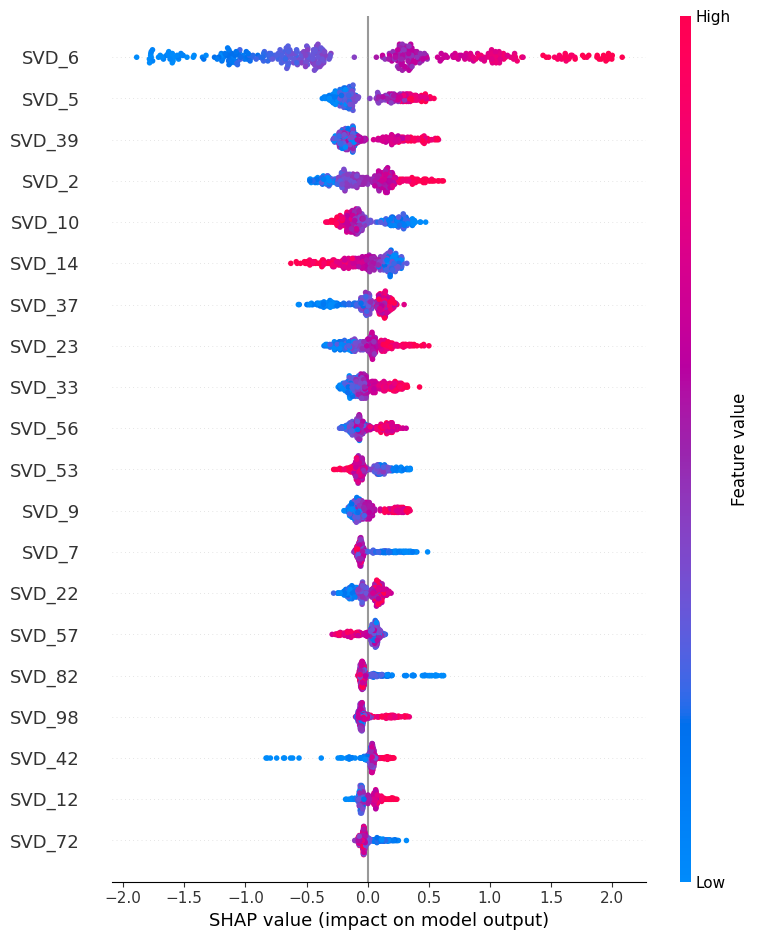

In [15]:
# (1) Apply SHAP using TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Handle possible list output format for binary classification
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# (2) Create feature names for SVD components
svd_feature_names = [f"SVD_{i+1}" for i in range(X_test.shape[1])]

# Generate SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=svd_feature_names)

## Question 4.2: Identify top concepts

Find the top 5 most important SVD components by mean absolute SHAP value. For each one, list the 5 words with the highest positive loading and the 5 words with the most negative loading. Then give each component a short descriptive name based on the words (e.g., "Positive Sentiment vs. Product Descriptions").

In [16]:
# Identify the top 5 most important SVD components by mean absolute SHAP values
# shap_values expected shape: (n_samples, n_components)
if isinstance(shap_values, list):
    shap_array = shap_values[1]
else:
    shap_array = shap_values

mean_abs_shap = np.abs(shap_array).mean(axis=0)
top5_components = np.argsort(mean_abs_shap)[-5:][::-1]

print("Top 5 most important SVD components by mean |SHAP|:\n")

for comp_idx in top5_components:
    loadings = svd.components_[comp_idx]

    # 5 words with highest positive loading
    pos_idx = np.argsort(loadings)[-5:][::-1]
    pos_words = [word_list[i] for i in pos_idx]

    # 5 words with most negative loading
    neg_idx = np.argsort(loadings)[:5]
    neg_words = [word_list[i] for i in neg_idx]

    # Simple descriptive name based on strongest positive vs negative words
    component_name = f"{pos_words[0].title()} / {pos_words[1].title()} vs {neg_words[0].title()} / {neg_words[1].title()}"

    print(f"Component SVD_{comp_idx + 1}")
    print(f"Mean |SHAP|: {mean_abs_shap[comp_idx]:.6f}")
    print(f"Top + words: {pos_words}")
    print(f"Top - words: {neg_words}")
    print(f"Suggested name: {component_name}")
    print("-" * 70)

Top 5 most important SVD components by mean |SHAP|:

Component SVD_6
Mean |SHAP|: 0.843714
Top + words: ['love', 'great', 'good', 'best', 'price']
Top - words: ['product', 'like', 'dog', 'tea', 'coffee']
Suggested name: Love / Great vs Product / Like
----------------------------------------------------------------------
Component SVD_5
Mean |SHAP|: 0.231168
Top + words: ['dog', 'tea', 'coffee', 'food', 'treats']
Top - words: ['product', 'good', 'taste', 'like', 'tastes']
Suggested name: Dog / Tea vs Product / Good
----------------------------------------------------------------------
Component SVD_39
Mean |SHAP|: 0.206140
Top + words: ['recommend', 'products', 'treats', 'time', 'flavors']
Top - words: ['item', 'away', 'dog', 'received', 'organic']
Suggested name: Recommend / Products vs Item / Away
----------------------------------------------------------------------
Component SVD_2
Mean |SHAP|: 0.204656
Top + words: ['coffee', 'tea', 'flavor', 'cup', 'taste']
Top - words: ['dog', 'fo

**Written answer:**



## Question 4.3: SHAP dependence plot

Create a SHAP dependence plot for the most important SVD component (from Question 4.2), coloring by the second most important component as the interaction feature.

How does the top component's value relate to its SHAP value? How does the second component affect this relationship?

Most important component: SVD_6
Second most important component: SVD_5


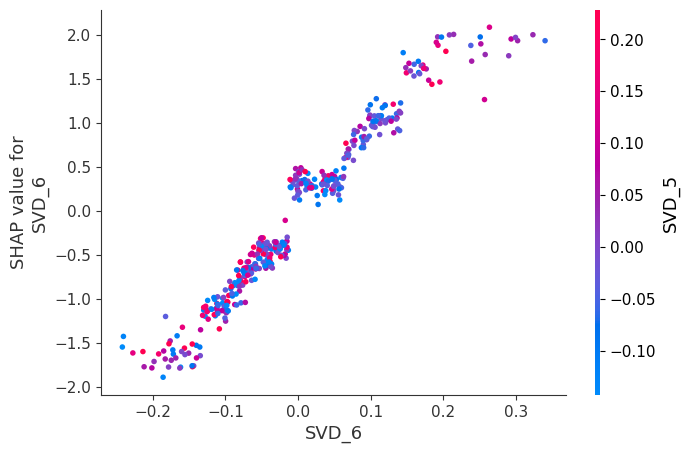

In [17]:
# Create a SHAP dependence plot
# x-axis: most important SVD component
# color: second most important SVD component

# Recompute rankings from SHAP values to ensure this cell is self-contained
if isinstance(shap_values, list):
    shap_array = shap_values[1]
else:
    shap_array = shap_values

mean_abs_shap = np.abs(shap_array).mean(axis=0)
top2_components = np.argsort(mean_abs_shap)[-2:][::-1]
main_comp = int(top2_components[0])
interaction_comp = int(top2_components[1])

print(f"Most important component: SVD_{main_comp + 1}")
print(f"Second most important component: SVD_{interaction_comp + 1}")

# SHAP dependence plot for top component, colored by second component
shap.dependence_plot(
    ind=main_comp,
    shap_values=shap_array,
    features=X_test,
    feature_names=[f"SVD_{i+1}" for i in range(X_test.shape[1])],
    interaction_index=interaction_comp
)

**Written answer:**

The dependence plot shows a clear relationship between the top SVD component value and its SHAP value: as the component score changes, its contribution to the model output shifts in a systematic way (from pushing predictions more negative to more positive, or vice versa). This indicates the component captures an important semantic direction used by the classifier.

Coloring by the second most important component shows interaction effects: for the same value of the top component, different values of the second component can change the SHAP impact. In other words, the model does not use the top concept alone; it combines it with another latent concept to adjust prediction strength.

## Question 4.4: Interpret the pipeline

Think about the full pipeline: TF-IDF → SVD → XGBoost → SHAP. Using the concept names from Question 4.2, explain how the model tells positive and negative reviews apart. What are the pros and cons of interpreting a text classifier through SVD components instead of individual words?

**Written answer:**

In this pipeline, TF-IDF first converts reviews into word-weight features, SVD then compresses those words into a smaller set of latent semantic components, XGBoost learns nonlinear decision boundaries using those components, and SHAP explains which components drive each prediction.

Using the concept names from Question 4.2, the model distinguishes positive vs negative reviews by combining multiple latent themes (for example, product praise/value language vs complaint/problem language). Positive predictions are pushed by components associated with favorable product experience terms, while negative predictions are pushed by components associated with dissatisfaction-related terms.

Pros of interpreting through SVD components:
- Reduces dimensionality and noise, making modeling faster and often more stable.
- Captures broader semantic patterns instead of isolated words.
- Makes global interpretation manageable (few components instead of thousands of words).

Cons:
- Components are less intuitive than individual words and can mix multiple topics.
- Information is compressed, so some fine-grained word-level detail is lost.
- Naming components is somewhat subjective, which can reduce interpretability clarity.

# End of Assignment 7